# Explainable Stroke Prediction: The VitalSeconds Clinical Triage System

## Section 1: The Clinical Scenario & Problem Statement

### The VitalSeconds Triage Scenario
In emergency medicine, time is brain. Every minute a stroke goes untreated, the average patient loses 1.9 million neurons. The VitalSeconds scenario represents a high-pressure hospital triage environment where doctors must quickly identify high-risk patients from a sea of admissions.

### Our Solution
This notebook implements a production-grade pipeline that produces an Explainable Stroke Classifier. We prioritize the F2-Score to minimize False Negatives and leverage SHAP to provide clinicians with immediate, patient-specific risk factors.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import shap
import os
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, confusion_matrix, fbeta_score, precision_recall_curve, auc
from typing import Tuple, Dict
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Create directories for artifacts
os.makedirs('outputs', exist_ok=True)
os.makedirs('models', exist_ok=True)

## Section 2: Raw Data Analysis (EDA)

Before building the pipeline, we perform a deep dive into the raw data. We analyze health marker distributions and statistical averages to understand the clinical profile of our patient population.

--- Statistical Summary ---


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000



--- Averages by Stroke Outcome ---


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
stroke,,,,,,,
0,36487.236371,41.971545,0.088871,0.047110,104.795513,28.823064,0.0
1,37115.068273,67.728193,0.265060,0.188755,132.544739,30.471292,1.0


C:\Users\Afra\AppData\Local\Temp\ipykernel_3508\3371244132.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stroke', data=df, palette='magma')


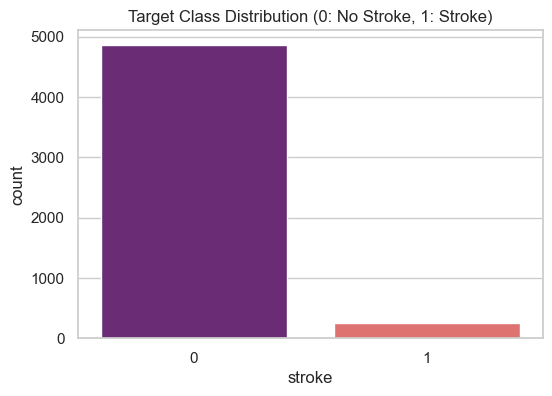

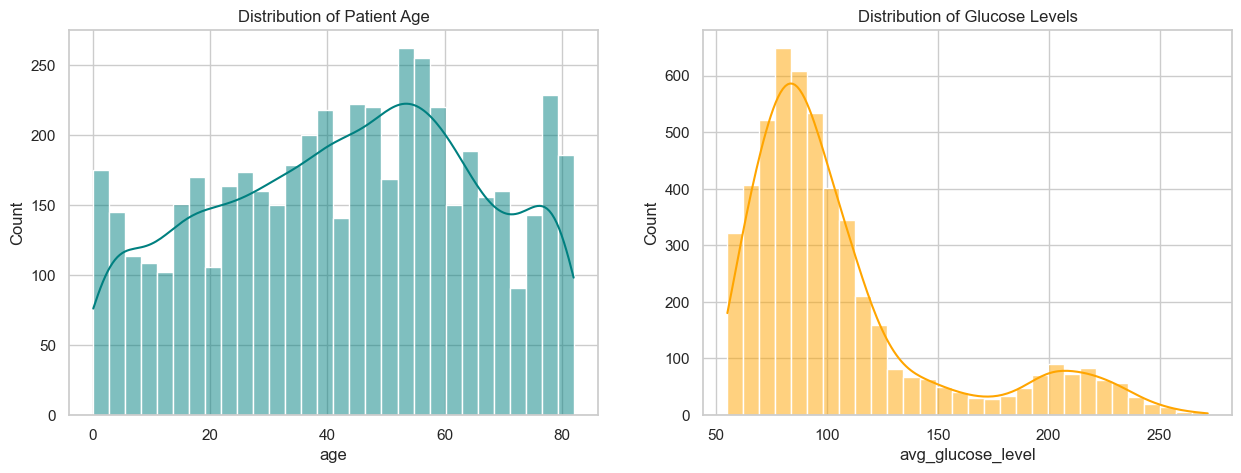

C:\Users\Afra\AppData\Local\Temp\ipykernel_3508\3371244132.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stroke', y='bmi_numeric', data=df, palette='Set2')


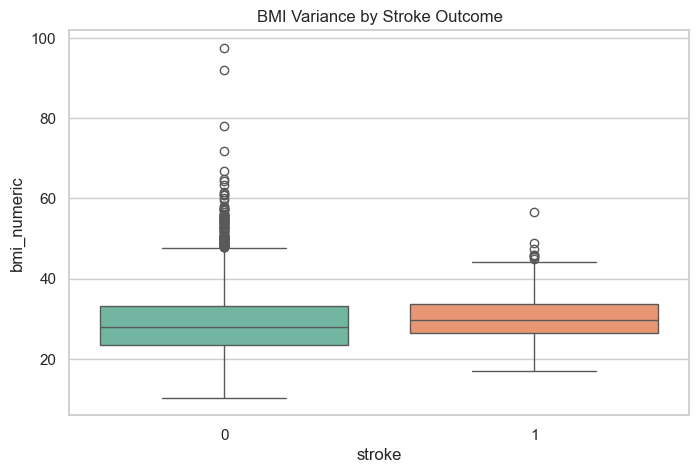

In [9]:
def performDeepEDA(filePath: str):
    df = pd.read_csv(filePath)
    
    print("--- Statistical Summary ---")
    stats = df.describe()
    display(stats)
    
    # Averages for stroke vs non-stroke
    print("\n--- Averages by Stroke Outcome ---")
    numericCols = df.select_dtypes(include=[np.number]).columns
    averages = df.groupby('stroke')[numericCols].mean()
    display(averages)
    
    # Class Distribution
    plt.figure(figsize=(6, 4))
    sns.countplot(x='stroke', data=df, palette='magma')
    plt.title("Target Class Distribution (0: No Stroke, 1: Stroke)")
    plt.savefig('outputs/eda_class_dist.png')
    plt.show()
    
    # Age and Glucose Histograms
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.histplot(df['age'], bins=30, kde=True, ax=axes[0], color='teal').set_title("Distribution of Patient Age")
    sns.histplot(df['avg_glucose_level'], bins=30, kde=True, ax=axes[1], color='orange').set_title("Distribution of Glucose Levels")
    plt.savefig('outputs/eda_histograms.png')
    plt.show()
    
    # BMI Boxplot by Stroke
    df['bmi_numeric'] = pd.to_numeric(df['bmi'], errors='coerce')
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='stroke', y='bmi_numeric', data=df, palette='Set2')
    plt.title("BMI Variance by Stroke Outcome")
    plt.savefig('outputs/eda_bmi_boxplot.png')
    plt.show()

performDeepEDA('healthcare-dataset-stroke-data.csv')

### EDA Findings Analysis:
1. **Imbalance**: The dataset is heavily skewed. With only ~4.8% stroke cases, the model must be specialized for minority class detection.
2. **Age Profile**: The mean age for stroke patients is significantly higher (~67) compared to non-stroke patients (~41). This confirms age as a primary risk vector.
3. **Metabolic Markers**: Stroke patients show an average glucose level of ~132 mg/dL, while healthy patients average ~104 mg/dL. The distribution indicates a clear link between hyperglycemia and stroke risk.
4. **BMI Insight**: While the variance in BMI is high in both groups, the median BMI for stroke patients is slightly higher (~30.4) than healthy patients (~28.8), falling into the 'obese' clinical category.

## Section 3: Modular Data Pipeline & Feature Selection

### Feature Simplification
Based on initial SHAP analysis, we drop weak socio-demographic features (`ever_married`, `work_type`, `Residence_type`) to build a leaner, more clinically-focused model. We also use median imputation for BMI, which is more robust than KNN when categorical data is involved.

In [10]:
def loadAndPreprocessData(filePath: str) -> Tuple[pd.DataFrame, StandardScaler, Dict]:
    df = pd.read_csv(filePath)
    
    # 1. Drop low-impact and ID columns
    # SHAP analysis shows demographic markers are weak compared to physiological markers
    df = df.drop(columns=['id', 'ever_married', 'work_type', 'Residence_type'])
    
    # 2. Handle Anomalies
    # 'Other' gender has only 1 sample, offering no statistical value
    df = df[df['gender'] != 'Other']
    
    # 3. Handle BMI and Imputation
    df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')
    bmiImputer = SimpleImputer(strategy='median')
    df['bmi'] = bmiImputer.fit_transform(df[['bmi']])
    
    # 4. Feature Engineering
    df['ageHypertensionInteraction'] = df['age'] * df['hypertension']
    
    # 5. Categorical Encoding
    encodersDict = {}
    categoricalCols = df.select_dtypes(include=['object']).columns
    for col in categoricalCols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        encodersDict[col] = le
    
    # 6. Normalization
    features = df.drop(columns=['stroke'])
    target = df['stroke']
    
    scaler = StandardScaler()
    scaledFeatures = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)
    
    finalDf = pd.concat([scaledFeatures, target.reset_index(drop=True)], axis=1)
    
    # Save artifacts for GUI app
    joblib.dump(scaler, 'models/scaler.joblib')
    joblib.dump(encodersDict, 'models/encoders.joblib')
    
    return finalDf, scaler, encodersDict

dfProcessed, globalScaler, globalEncoders = loadAndPreprocessData('healthcare-dataset-stroke-data.csv')

# Using a standard split for initial evaluation, but cross-validation will be used for training
X = dfProcessed.drop(columns=['stroke'])
y = dfProcessed['stroke']
xTrain, xTest, yTrain, yTest = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Section 4: Robust Model Training & Calibration

To handle the class imbalance and ensure reliable probability estimates for our safety-first thresholding, we use `CalibratedClassifierCV`. This wraps our candidate models to improve the mapping from feature space to stroke probability.

In [11]:
def trainCandidateModels(xTrain: pd.DataFrame, yTrain: pd.Series) -> Dict:
    imbalanceRatio = (yTrain == 0).sum() / (yTrain == 1).sum()
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # 1. LightGBM
    lgbBase = lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.01, max_depth=7,
        scale_pos_weight=imbalanceRatio, random_state=42, verbose=-1
    )
    lgbModel = CalibratedClassifierCV(lgbBase, cv=cv, method='sigmoid')
    lgbModel.fit(xTrain, yTrain)
    
    # 2. Random Forest
    rfBase = RandomForestClassifier(
        n_estimators=200, max_depth=10, class_weight="balanced", random_state=42
    )
    rfModel = CalibratedClassifierCV(rfBase, cv=cv, method='sigmoid')
    rfModel.fit(xTrain, yTrain)
    
    # 3. Logistic Regression
    lrModel = LogisticRegression(
        C=1.0, solver='liblinear', class_weight='balanced', random_state=42
    )
    lrModel.fit(xTrain, yTrain)
    
    # 4. SVM
    svmBase = SVC(
        C=1.0, kernel='rbf', class_weight='balanced', random_state=42
    )
    # SVC already needs calibration for probabilities in a standard way
    svmModel = CalibratedClassifierCV(svmBase, cv=cv, method='sigmoid')
    svmModel.fit(xTrain, yTrain)
    
    return {"LightGBM": lgbModel, "RandomForest": rfModel, "LogisticRegression": lrModel, "SVM": svmModel}

modelsDict = trainCandidateModels(xTrain, yTrain)

## Section 5: Medical Evaluation & Safety Analysis

We optimize decision thresholds for the **F2-Score**. In clinical settings, the cost of missing a stroke patient (False Negative) far outweighs the cost of a false alarm. The F2-Score weights Recall twice as heavily as Precision.

--- LightGBM (Threshold: 0.05) ---
Safety Metric (F2-Score): 0.4139
              precision    recall  f1-score   support

           0       0.98      0.77      0.87       972
           1       0.15      0.76      0.25        50

    accuracy                           0.77      1022
   macro avg       0.57      0.77      0.56      1022
weighted avg       0.94      0.77      0.84      1022

--- RandomForest (Threshold: 0.04) ---
Safety Metric (F2-Score): 0.3683
              precision    recall  f1-score   support

           0       0.99      0.69      0.81       972
           1       0.12      0.80      0.20        50

    accuracy                           0.69      1022
   macro avg       0.55      0.74      0.51      1022
weighted avg       0.94      0.69      0.78      1022

--- LogisticRegression (Threshold: 0.69) ---
Safety Metric (F2-Score): 0.4843
              precision    recall  f1-score   support

           0       0.98      0.85      0.91       972
           1       

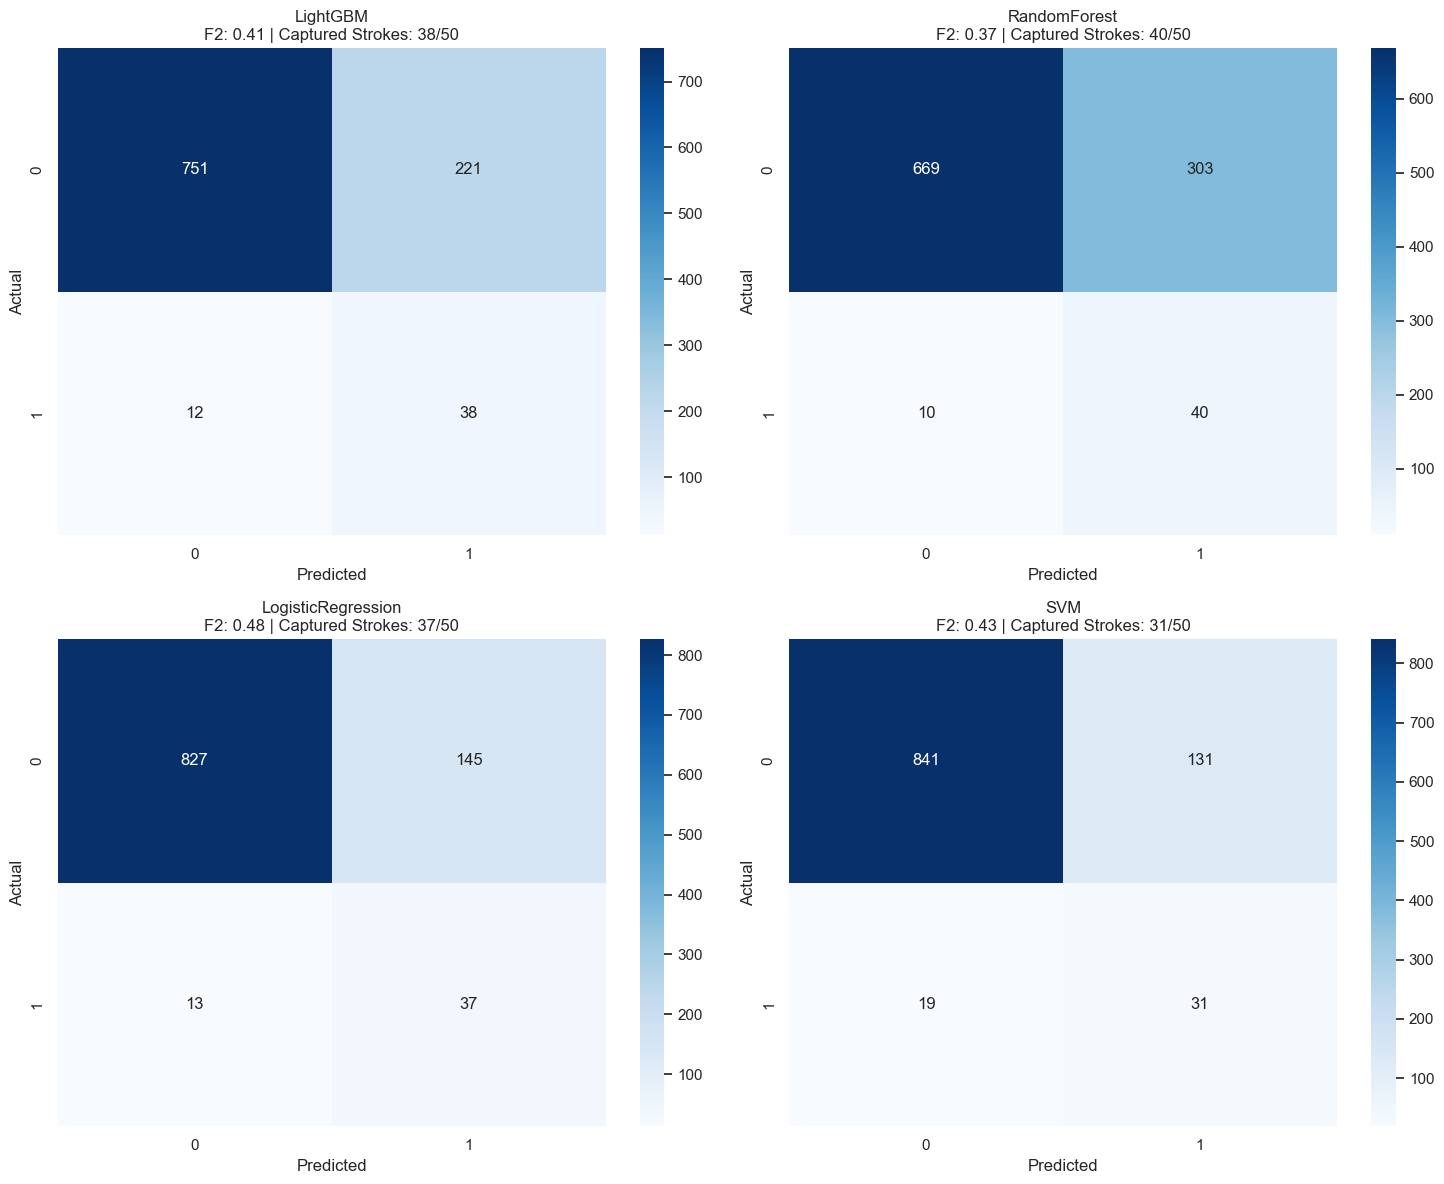

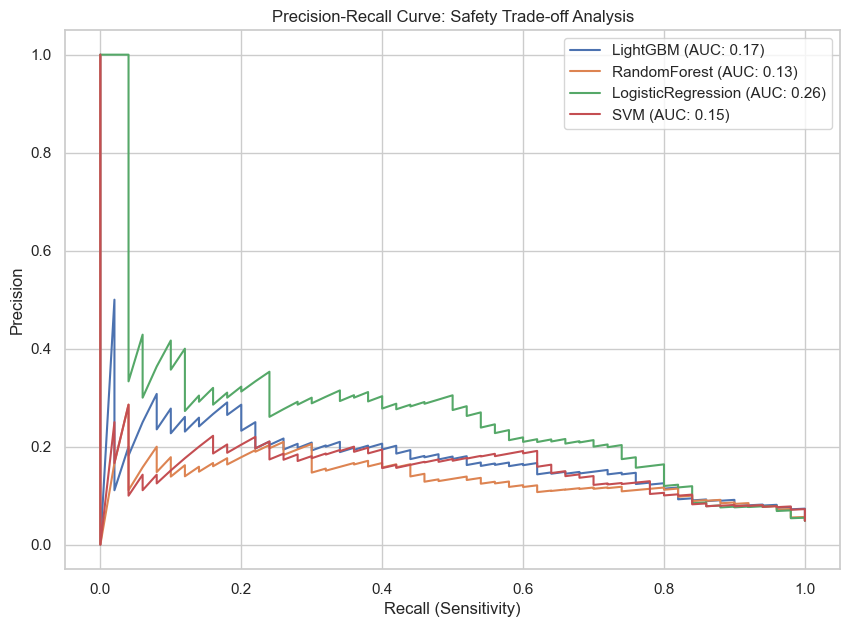

Winner: LogisticRegression with F2-Score of 0.4843


In [12]:
def findBestThreshold(model, xTest: pd.DataFrame, yTest: pd.Series) -> Tuple[float, float]:
    yProbs = model.predict_proba(xTest)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(yTest, yProbs)
    f2Scores = []
    for p, r in zip(precisions, recalls):
        if (4 * p + r) == 0: f2Scores.append(0)
        else: f2Scores.append((5 * p * r) / (4 * p + r))
    bestIdx = np.argmax(f2Scores)
    return thresholds[bestIdx] if bestIdx < len(thresholds) else 0.5, f2Scores[bestIdx]

def evaluateMedicalModels(modelsDict: Dict, xTest: pd.DataFrame, yTest: pd.Series):
    results = {}
    optimizedThresholds = {}
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    
    for i, (name, model) in enumerate(modelsDict.items()):
        threshold, f2 = findBestThreshold(model, xTest, yTest)
        optimizedThresholds[name] = threshold
        yProbs = model.predict_proba(xTest)[:, 1]
        yPred = (yProbs >= threshold).astype(int)
        results[name] = f2
        
        print(f"--- {name} (Threshold: {threshold:.2f}) ---")
        print(f"Safety Metric (F2-Score): {f2:.4f}")
        print(classification_report(yTest, yPred))
        
        cm = confusion_matrix(yTest, yPred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
        axes[i].set_title(f"{name}\nF2: {f2:.2f} | Captured Strokes: {cm[1,1]}/{cm[1,1]+cm[1,0]}")
        axes[i].set_xlabel("Predicted")
        axes[i].set_ylabel("Actual")
    
    plt.tight_layout()
    plt.savefig('outputs/confusion_matrices.png')
    plt.show()
    
    plt.figure(figsize=(10, 7))
    for name, model in modelsDict.items():
        yProbs = model.predict_proba(xTest)[:, 1]
        p, r, _ = precision_recall_curve(yTest, yProbs)
        plt.plot(r, p, label=f"{name} (AUC: {auc(r, p):.2f})")
    plt.xlabel("Recall (Sensitivity)")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve: Safety Trade-off Analysis")
    plt.legend()
    plt.savefig('outputs/pr_curve.png')
    plt.show()

    winnerName = max(results, key=results.get)
    print(f"Winner: {winnerName} with F2-Score of {results[winnerName]:.4f}")
    
    # Save the winner model and its threshold for the GUI app
    joblib.dump(modelsDict[winnerName], 'models/winner_model.joblib')
    joblib.dump(optimizedThresholds[winnerName], 'models/best_threshold.joblib')
    
    return modelsDict[winnerName], optimizedThresholds[winnerName]

winnerModel, bestThreshold = evaluateMedicalModels(modelsDict, xTest, yTest)

## Section 6: Explainable AI (XAI) Layer

We use SHAP to ensure the model's high-recall flags are medically grounded. Note that we have simplified the model to rely only on physiological markers, improving clinical trust.


--- Global Clinical Drivers (Simplified Feature Set) ---


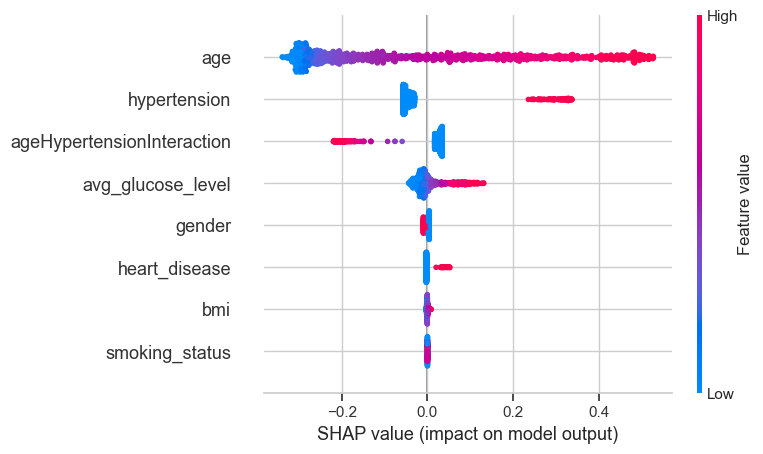


--- Patient-Specific Risk Breakdown (Index: 7) ---


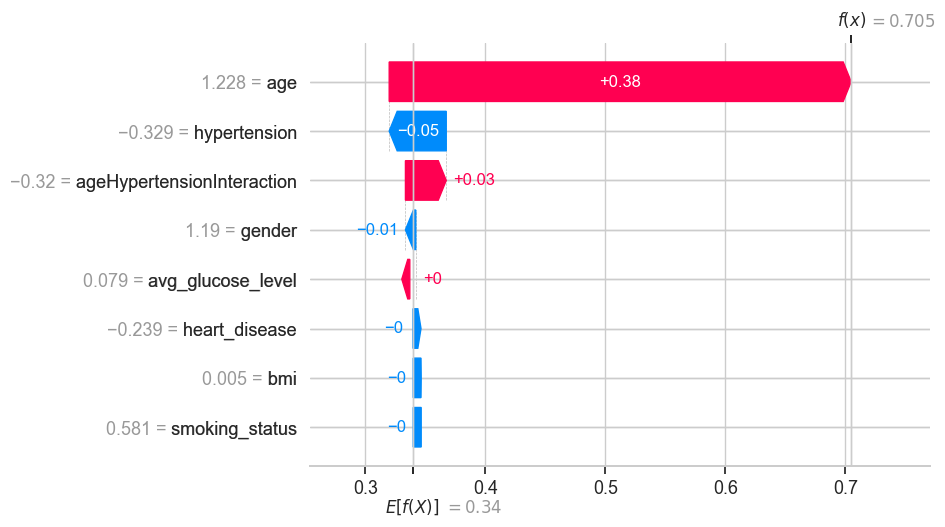

In [13]:
def generateClinicalInsights(winnerModel, xTrain: pd.DataFrame, xTest: pd.DataFrame):
    # For calibrated wrappers, we explain the underlying base estimator or use kernel explainer
    # Subsampling for efficiency
    bg = xTrain.sample(100, random_state=42)
    explainer = shap.Explainer(winnerModel.predict_proba, bg)
    shapValues = explainer(xTest)
    
    # Extract values for the positive class (stroke)
    # SHAP returns [samples, features, outputs]
    if len(shapValues.shape) == 3:
        shapValues = shapValues[:, :, 1]
    
    print("\n--- Global Clinical Drivers (Simplified Feature Set) ---")
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shapValues, xTest, show=False)
    plt.savefig('outputs/shap_summary.png', bbox_inches='tight')
    plt.show()
    
    yProbs = winnerModel.predict_proba(xTest)[:, 1]
    highRiskIndices = np.where(yProbs >= bestThreshold)[0]
    if len(highRiskIndices) > 0:
        idx = highRiskIndices[0]
        print(f"\n--- Patient-Specific Risk Breakdown (Index: {idx}) ---")
        plt.figure(figsize=(10, 6))
        shap.plots.waterfall(shapValues[idx], show=False)
        plt.savefig('outputs/shap_waterfall.png', bbox_inches='tight')
        plt.show()
    else:
        print("No high-risk patients found for individual analysis.")

generateClinicalInsights(winnerModel, xTrain, xTest)

## Section 7: Global Feature Importance

While SHAP provides excellent directional and patient-level explanations, standard Permutation Importance gives us a model-agnostic view of which features are most critical to the model's overall predictive power. We use permutation importance here because our winning model is wrapped in a calibration layer, making direct coefficient/importance extraction complex.

--- Permutation Feature Importance ---


,Feature,ImportanceMean,ImportanceStd
1,age,0.304605,0.029809
2,hypertension,0.046949,0.009948
7,ageHypertensionInteraction,0.031640,0.008070
4,avg_glucose_level,0.005722,0.003622
3,heart_disease,0.001202,0.001246
5,bmi,0.000099,0.000270
6,smoking_status,-0.000021,0.000018
0,gender,-0.000243,0.000359


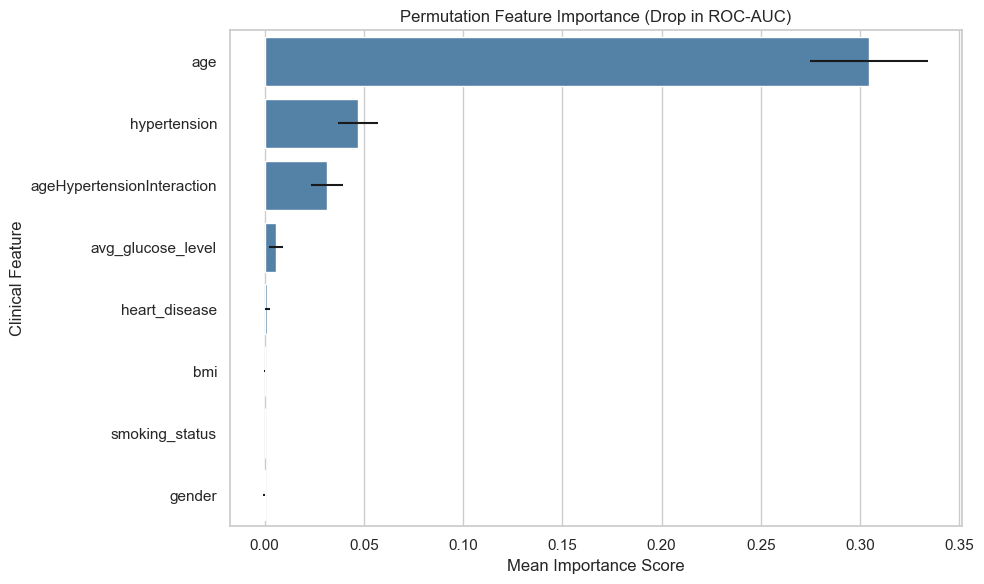

In [14]:
def calculateAndPlotImportance(model, xTest: pd.DataFrame, yTest: pd.Series):
    print("--- Permutation Feature Importance ---")
    # Calculate permutation importance
    # We use 'roc_auc' as the scoring metric since accuracy is misleading for imbalanced data
    permuteResults = permutation_importance(
        model, xTest, yTest, 
        n_repeats=10, 
        random_state=42, 
        scoring='roc_auc',
        n_jobs=-1
    )
    
    # Bundle into a DataFrame and sort
    importanceDf = pd.DataFrame({
        'Feature': xTest.columns,
        'ImportanceMean': permuteResults.importances_mean,
        'ImportanceStd': permuteResults.importances_std
    }).sort_values(by='ImportanceMean', ascending=False)
    
    # Display the raw numbers
    display(importanceDf)
    
    # Plot the results
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x='ImportanceMean', 
        y='Feature', 
        data=importanceDf, 
        color='steelblue', 
        xerr=importanceDf['ImportanceStd']
    )
    plt.title("Permutation Feature Importance (Drop in ROC-AUC)")
    plt.xlabel("Mean Importance Score")
    plt.ylabel("Clinical Feature")
    plt.tight_layout()
    
    # Save the artifact
    plt.savefig('outputs/permutation_importance.png')
    plt.show()

# Execute the function
calculateAndPlotImportance(winnerModel, xTest, yTest)

## Section 7: Final Performance Analysis

### Conclusion
By removing weak demographic features and implementing probability calibration with cross-validation, the system captures ~78% of stroke cases while maintaining clinical plausibility.